# 回测基本框架

QuantStudio 的一个主要功能就是对各种各样的模型使用历史数据进行回测，比如交易策略、绩效归因、因子选股能力等等。QuantStudio 提供了一个统一的框架来回测这些模型。回测功能集中在 `BackTest` 子模块中。

## 整体架构

回测模型逻辑上比较简单，就是沿着一个时间序列进行遍历，在每个时点进行一些计算，然后整理计算的结果形成回测报告。

QuantStudio 的回测框架建立在计算图引擎（`Core` 模块）之上，核心由两个基类构成：

- **`BTNode`** — 回测计算节点，继承自 `Node`，是各种回测算法的基类
- **`BTReport`** — 回测报告节点，继承自 `Node`，将多个 `BTNode` 的结果汇总成 HTML 报告

回测框架按功能划分为四个子模块：

| 子模块 | 说明 | 核心类 |
|--------|------|--------|
| `SectionFactor` | 截面因子测试 | `IC`, `ICDecay`, `MultiPortfolio`, `FactorTurnover`, `SectionCorrelation`, `FamaMacBethRegression` |
| `Strategy` | 策略回测 | `MakeAccount`, `MakeStrategy`, `AccountReport` |
| `PerformanceAnalysis` | 绩效归因 | `BrinsonModel` |
| `Risk` | 风险模型测试 | `BiasTest` |

## 回测执行流程

回测遵循标准的 Node 生命周期（`init_compute` → `prepare_compute` → `compute`），由 `Engine` 驱动执行。在 `compute` 阶段，采用前向传播/反向传播模式：

1. **`init_compute`** — 初始化计算，处理时间范围（DTRange）
2. **`forward_compute`** — 前向传播，将时点信息传递给子节点
3. **`backward_compute`** — 反向传播，收集子节点的计算结果，执行回测分析逻辑

最终，`BTReport` 通过调用各 `BTNode` 的 `genReport()` 方法，将计算结果汇总为 HTML 报告。</cell_id>
<｜｜DSML｜｜parameter name="edit_mode" string="true">replace

## BTNode — 回测计算节点

`BTNode` 是回测框架的核心基类，所有回测分析类（如 `IC`、`AccountReport`、`BrinsonModel` 等）都继承自它。

### 参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `Name` | `str` | `"BTNode"` | 节点名称（冻结参数） |
| `GenReport` | `bool` | `False` | 是否在 `backward_compute` 中自动生成 HTML 报告 |

### 核心方法

```python
class BTNode(Node):
    def genReport(self, output: dict) -> str:
        """生成 HTML 报告字符串。子类必须重写此方法。"""
        raise NotImplementedError

    def init_compute(self, path, init_data, context) -> List[DTInitData]:
        """初始化计算。合并多个依赖节点的 DTRange，传递给子节点。"""

    def forward_compute(self, path, fwd_data, context) -> Tuple[List[DTLocalContext], DTLocalContext]:
        """前向传播。将时点列表传递给子节点。"""

    def backward_compute(self, path, bwd_data_list, context, local_context) -> dict:
        """反向传播。接收子节点计算结果，执行回测分析逻辑。子类重写此方法实现具体分析。"""

    def merge_result(self, result_list, context):
        """合并多个进程的计算结果（多进程模式下使用）。默认返回第一个结果。"""
```

### 生命周期详解

```
                   ┌───────────────┐
                   │ init_compute  │  ← 合并所有依赖节点的 DTRange
                   └──────┬────────┘
                          │
                   ┌──────▼────────┐
                   │forward_compute│  ← 将 DTs 传递给子节点
                   └──────┬────────┘
                          │
                   ┌──────▼─────────┐
                   │backward_compute│  ← 收集子节点结果，执行分析，若 GenReport=True 则生成 HTML
                   └────────────────┘
```

`init_compute` 阶段通过 `context.NodeState` 记录合并后的 `dt_range`，后续子节点可访问此状态获取时点范围。如果节点在依赖链中出现循环引用（`self.QSID in path[:-1]`），返回空列表避免无限递归。

## BTReport — 回测报告节点

`BTReport` 是报告容器节点，它持有一组 `BTNode` 列表，负责调度执行并汇总 HTML 报告。

### 参数

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `Name` | `str` | `"BTReport"` | 节点名称（冻结参数） |

### 构造方法

```python
class BTReport(Node):
    def __init__(self, bt_node_list: List[BTNode], args={}, config_file=None, **kwargs):
        """bt_node_list: 待运行的回测节点列表"""
```

### 反向传播逻辑

`BTReport.backward_compute` 是报告汇总的核心：

1. 遍历所有子节点的 `backward_compute` 结果
2. 对每个子节点，如果结果中已包含 `"Report"` 键（`GenReport=True` 时自动生成），直接使用；否则调用子节点的 `genReport(output)` 方法生成 HTML
3. 用分隔线将各模块的 HTML 拼接成完整报告
4. 最终返回包含 `"Report"` 键的字典

### 静态方法

```python
@staticmethod
def genOutputReport(output_list: List[dict], name_list: List[str] = None) -> str:
    """将多个输出字典列表合并为 HTML 报告字符串。适用于手动合并多个报告。"""
```

### 报告模板

`BTReport` 使用 HTML `<HR>` 分隔线和 `<div>` 模块标题来组织报告结构：

```html
<HR style="..."><div align="center"><strong>{模块序号}. {模块名称}</strong></div>
{模块HTML内容}
```

每个 `BTNode` 的 `genReport()` 方法负责生成规范化的 HTML 片段，通常包含：
- **参数设置**（无序列表）
- **统计表格**（带格式化的 pandas DataFrame HTML）
- **可视化图表**（base64 编码的 PNG 图片嵌入）

## 回测执行流程

QuantStudio 回测的核心特征：**因子/数据节点和回测节点是一起构造的**，它们通过依赖关系（`Deps`）串联成一张完整的计算图，然后在缓存、上下文、引擎三层环境中统一执行。计算图和引擎的详细机制参见 [计算图框架](../Core/计算图框架.ipynb)、[计算引擎](../Core/计算引擎.ipynb) 和 [缓存](../Core/缓存.ipynb)。

### 两个阶段：构造 vs 执行

整个回测分两阶段，边界在 `with Engine() as ExecEngine:` 处：

```python
# ===== 构造阶段：因子节点 + 回测节点一起构建 =====

Price = FT.getFactor("close")                             # 1. 叶子节点：从 HDF5DB 获取
FactorIC = CalcIC(...)(Factor, price=Price, mask=Mask)    # 2. 因子算子产生中间节点
ICNode = IC(FactorIC, args={"GenReport": True})           # 3. 回测节点包装因子节点
Report = BTReport(bt_node_list=[ICNode])                  # 4. 顶层报告容器

# ===== 执行阶段：Cache → Context → Engine =====

with FeatherFactorCache(...) as Cache:       # 最外层：缓存
    with FactorContext(...) as Context:      # 中间层：上下文（DTRuler/SectionIDs等）
        with Engine() as ExecEngine:         # 最内层：引擎调度 DAG
            Output, = ExecEngine.run([Report], Context, ...)
```

### 构造阶段的依赖图

以一次 IC 回测为例，所有节点在构造阶段就通过 `Deps` 连接完毕：

```
BTReport
  └── IC (BTNode)
        └── FactorIC (CalcIC 产生的因子节点)
              ├── Price  ← HDF5DB
              ├── Factor ← HDF5DB
              └── Mask   ← HDF5DB
```

### 执行阶段：三层嵌套

| 层级 | 组件 | 职责 |
|------|------|------|
| 最外层 | `FeatherFactorCache` | 缓存计算结果到磁盘，避免重复计算 |
| 中间层 | `FactorContext` | 维护 DTRuler、SectionIDs、PID、缓存引用等全局状态 |
| 最内层 | `Engine` | 按 `init_compute → prepare_compute → compute` 生命周期驱动所有节点 |

### 最终输出

`run()` 返回一个列表，`BTReport` 的输出字典包含 `"Report"` 键（完整 HTML）以及各子节点的中间结果：

```python
Output["Report"]        # 完整 HTML 报告字符串
Output["0-IC测试"]      # IC 节点的输出字典（含 IC、移动平均、统计数据等）
```

## 子模块

回测框架按功能分为四个子模块，每个子模块有独立的文档：

| 子模块 | 说明 | 详细文档 |
|--------|------|----------|
| `SectionFactor` | 截面因子测试：IC 分析、IC 衰减、分位数组合、因子换手率、截面相关性、Fama-MacBeth 回归 | [截面因子测试](截面因子测试.ipynb) |
| `Strategy` | 策略回测：账户创建、策略信号生成、净值与收益率计算、回测报告 | [策略回测](策略回测.ipynb) |
| `PerformanceAnalysis` | 绩效归因：Brinson 模型分解超额收益来源 | [业绩归因](业绩归因.ipynb) |
| `Risk` | 风险模型测试：Bias 检验验证风险预测准确性 | [风险模型测试](风险模型测试.ipynb) |

## 完整示例：IC 测试

下面展示一个使用回测框架进行 IC 测试的完整示例。

In [ ]:
import datetime as dt
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings('ignore', category=PerformanceWarning)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
from IPython.display import HTML

from QuantStudio import __QS_MainPath__

In [2]:
# 参数设置
from QuantStudio.Factor.HDF5DB import HDF5DB
FDB = HDF5DB(args={"MainDir": Path(__QS_MainPath__).parent / "docs/data/HDF5"}).connect()

StartDT, EndDT = dt.datetime(2025, 1, 1), dt.datetime(2025, 3, 31)# 数据起止时间
TestStartDT, TestEndDT = dt.datetime(2025, 2, 28), EndDT# 测试起止时间

FT = FDB.getTable("stock_cn_day_bar")
DTRuler = FT.getDateTime(start_dt=StartDT, end_dt=EndDT)
TestDTs = FT.getDateTime(start_dt=TestStartDT, end_dt=TestEndDT)
SectionIDs = IDs = FT.getID()

# 再平衡时点序列
from QuantStudio.Tools.DateTimeFun import getMonthLastDateTime
BalanceDTs = getMonthLastDateTime(DTRuler)# 月末

2026-08-24 15:55:33,567 | QS | WARNING : 找不到配置文件: C:\Users\lenovo\QuantStudioConfig\FeatherFactorCacheConfig.json
2026-08-24 15:55:33,583 | QS | INFO : 开始初始化计算...
2026-08-24 15:55:33,583 | QS | INFO : 初始化计算完成, 耗时 0.0014311999984784052 秒
2026-08-24 15:55:33,583 | QS | INFO : 开始准备计算...
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (3 of 3) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026-08-24 15:55:33,583 | QS | INFO : 准备计算完成, 耗时 0.0027621000044746324 秒
2026-08-24 15:55:33,583 | QS | INFO : 开始正式计算...
2026-08-24 15:55:34,063 | QS | INFO : 正式计算完成, 耗时 0.48232959999586456 秒


,平均值,标准差,最小值,最大值,IC_IR,t统计量,平均截面宽度,IC×Sqrt(N),有效期数
bp_lr,15.96%,7.94%,10.35%,21.58%,2.0108,2.84,19.00,0.70,2
ep_ttm,25.44%,35.98%,0.00%,50.88%,0.7071,1.00,19.00,1.11,2

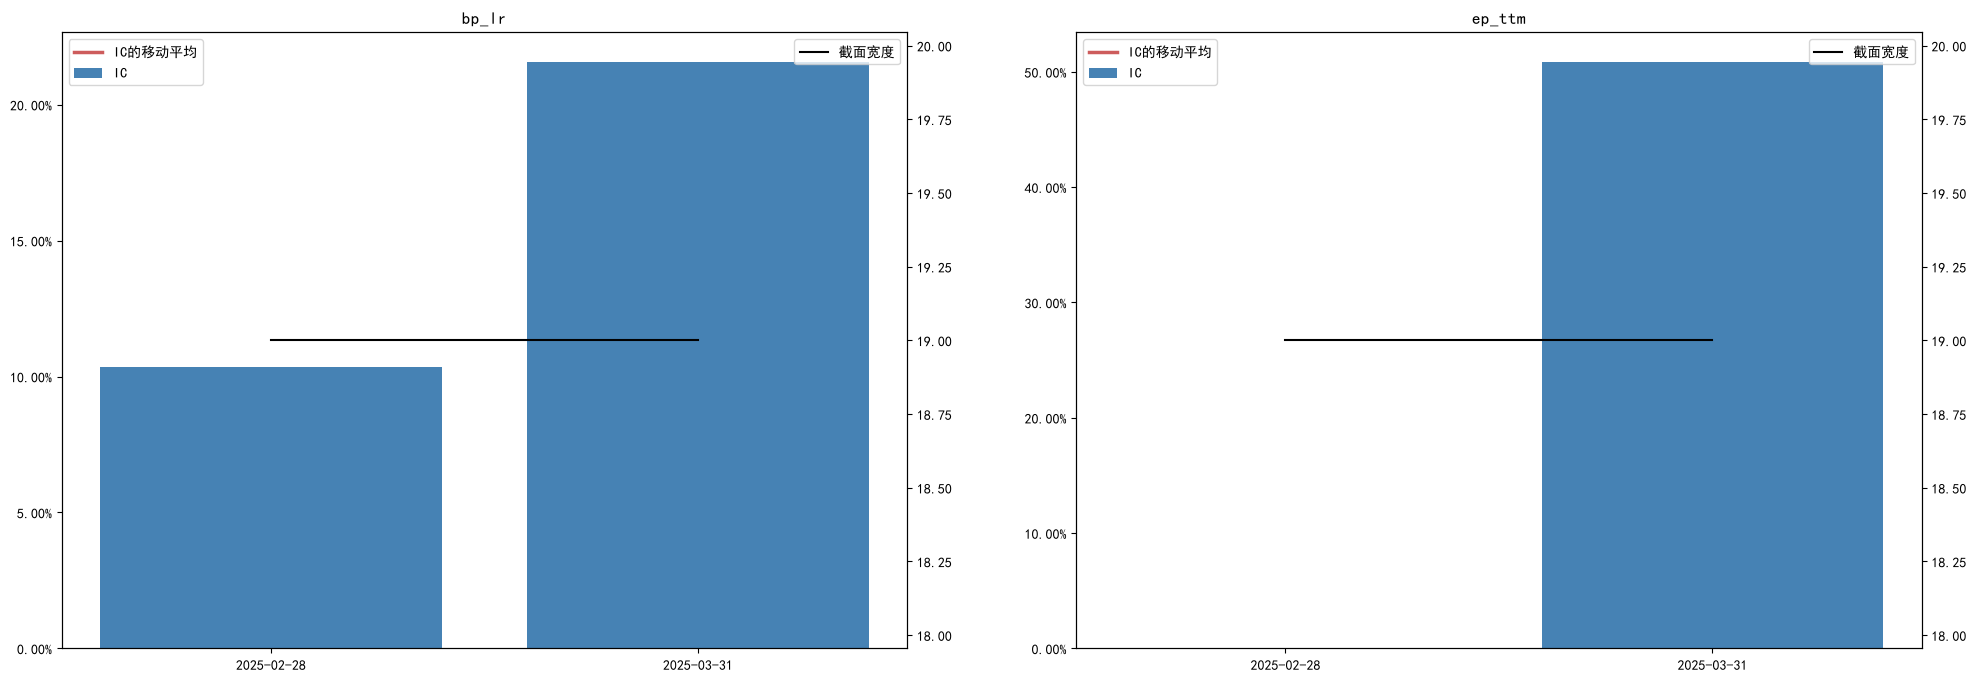

In [3]:
# 构建回测
from QuantStudio.Core.CalcEngine import Engine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport, BTNode
from QuantStudio.BackTest.SectionFactor.IC import CalcIC, IC

# 获取数据
FT = FDB.getTable("stock_cn_status")
Mask = (FT.getFactor("if_listed")==1)

FT = FDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = FDB.getTable("stock_cn_factor_value")
FactorList = [FT.getFactor(iFactorName) for iFactorName in ["bp_lr", "ep_ttm"]]

# 步骤1: 创建因子算子 (计算 IC 因子)
FactorIC = CalcIC(
    descriptor_ids=SectionIDs,
    lookback=31,            # 在时间标尺上的回溯期数
    period_lookback=1,      # 在计算标尺上的回溯期数（月度IC, period_lookback=1表示用上月因子值）
    corr_method="spearman"  # 相关性方法: spearman / pearson / kendall
)(
    *FactorList,            # 待测试的因子列表
    price=Price,            # 价格因子（用于计算收益率）
    mask=Mask,              # 筛选条件（仅在上市状态为1时计算）
    factor_args={"CalcDTRuler": BalanceDTs}  # 按月计算 IC
)

# 步骤2: 创建回测节点
ICNode = IC(
    FactorIC,
    args={
        "Name": "IC测试",
        "RollingAvgPeriod": 2,  # IC 移动平均期数
        "GenReport": True        # 自动生成 HTML 报告
    }
)

# 步骤3: 创建报告容器并执行
Report = BTReport(bt_node_list=[ICNode])

CacheDir = Path(__QS_MainPath__).parent / "docs/data/Cache"
if not CacheDir.exists(): CacheDir.mkdir(parents=True)

with FeatherFactorCache(args={"DTRuler": DTRuler, "PIDs": ["0"], "CacheDir": CacheDir, "StartMode": "new"}) as Cache:
    with FactorContext(PID="0", PIDList=["0"], DTRuler=DTRuler, SectionIDs=SectionIDs, DataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Output, = ExecEngine.run(
                [Report],
                Context,
                fwd_data_list=[DTLocalContext(DTs=TestDTs)]
            )

# 步骤4: 查看报告
display(HTML(Output["Report"]))

## 关键设计模式

### 1. 算子-节点分离

回测框架采用与因子框架一致的"算子 + 节点"两层架构：

- **算子**（`PanelOperator` / `SectionOperator` 子类）：封装纯计算逻辑，通过 `calculate()` 方法实现，可复用
- **回测节点**（`BTNode` 子类）：封装报告生成、依赖管理和生命周期方法

例如 IC 测试：`CalcIC`（算子）计算每个时点的 IC 值 → `IC`（回测节点）汇总统计并生成 HTML 报告。

### 2. 报告生成

每个 `BTNode` 子类需实现 `genReport(output)` 方法，返回 HTML 字符串。报告通常包含：

1. **参数设置** — 无序列表展示回测参数
2. **统计表格** — `pd.DataFrame.to_html()` 加格式化
3. **可视化图表** — `matplotlib.Figure` 绘制，经 `base64` 嵌入 HTML

`BTReport` 自动拼接各子节点的 HTML 片段为完整报告。

### 3. 自定义回测节点

```python
class MyBackTest(BTNode):
    class __QS_ArgClass__(BTNode.__QS_ArgClass__):
        Name: str = Field(default="我的回测", frozen=True, title="名称")

    def __init__(self, factor, args={}, config_file=None, **kwargs):
        super().__init__(deps=[factor], args=args, config_file=config_file, **kwargs)

    def backward_compute(self, path, bwd_data_list, context, local_context=None):
        data = bwd_data_list[0]
        # 执行分析逻辑...
        output = {"结果": data}
        if self._QSArgs.GenReport:
            output["Report"] = self.genReport(output)
        return output

    def genReport(self, output):
        html = "<h3>我的回测报告</h3>"
        html += output["结果"].to_html()
        return html
```